### Setting Environment

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Initialise Data

In [23]:
titanic = pd.read_csv("titanic.csv")
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [25]:
titanic['family size']= titanic['SibSp']+titanic['Parch']+1
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  family size  891 non-null    int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 90.6+ KB


### 1. Generate a series of bar charts to describe the gender, ticket class and survival of the passengers onboard. 

####  i.Generate a series of bar charts to describe the gender of the passengers onboard

<Axes: title={'center': 'Gender of Passengers Onboard'}, xlabel='Gender', ylabel='No. Of Passengers'>

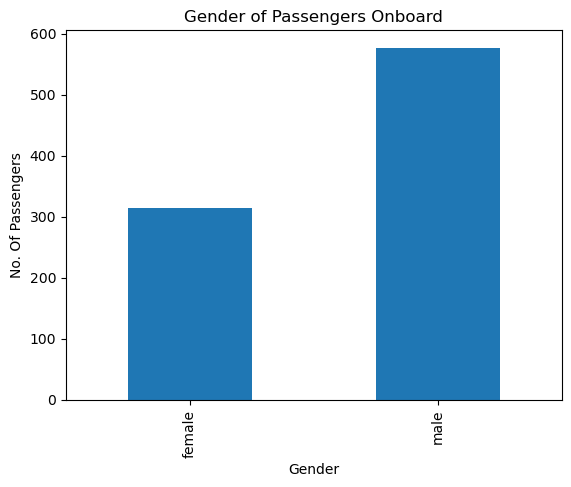

In [150]:
titanic.groupby('Sex').size().plot.bar(title='Gender of Passengers Onboard', ylabel="No. Of Passengers", xlabel="Gender")

####  ii.Generate a series of bar charts to describe the ticket class of the passengers onboard

[Text(0, 0, '1st'), Text(1, 0, '2nd'), Text(2, 0, '3rd')]

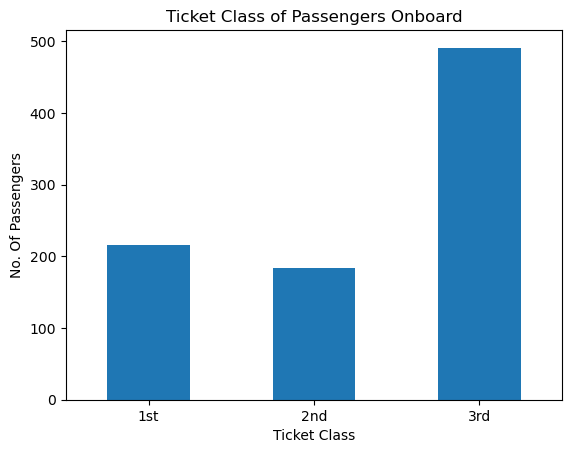

In [146]:
ax = titanic.groupby('Pclass').size().plot.bar(title='Ticket Class of Passengers Onboard', ylabel="No. Of Passengers", xlabel="Ticket Class")
ax.set_xticklabels(("1st","2nd","3rd"), rotation=0)

####  iii.Generate a series of bar charts to describe the survival of the passengers onboard

[Text(0, 0, 'No'), Text(1, 0, 'Yes')]

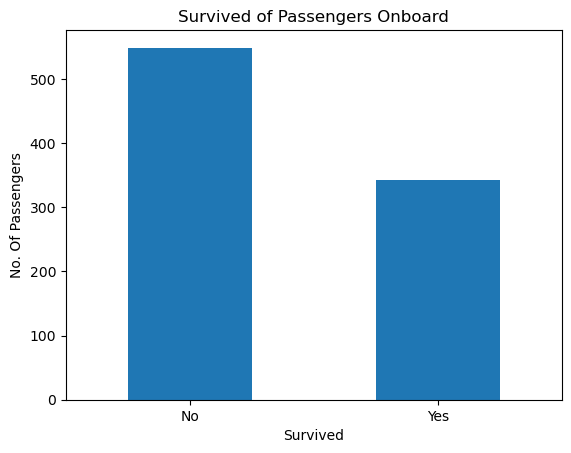

In [152]:
ax = titanic.groupby('Survived').size().plot.bar(title='Survived of Passengers Onboard', ylabel="No. Of Passengers", xlabel="Survived")
ax.set_xticklabels(("No","Yes"), rotation=0)

### 2. Generate a histogram for the passengers’ age. Furthermore, describe the passengers’ age using the following two boxplots: age per ticket class and age based on survival.

#### i. Generate a histogram for the passengers’ age.

<Axes: title={'center': 'Age of Passengers Onboard'}, ylabel='Frequency'>

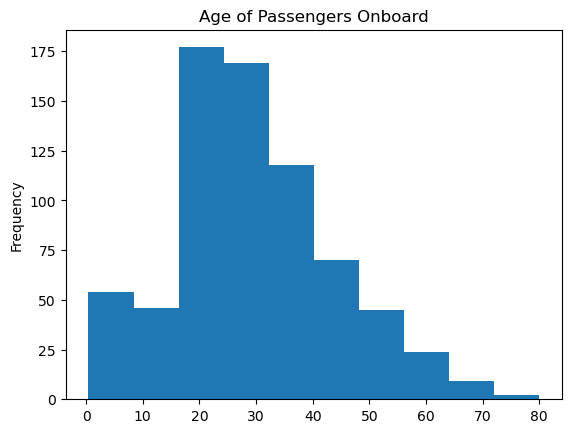

In [53]:
titanic['Age'].plot(kind='hist', title="Age of Passengers Onboard")

#### ii. describe the passengers’ age using boxplots on age per ticket class

C:\Users\shani\AppData\Local\Temp\ipykernel_22908\3945536130.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(("1st","2nd","3rd"))


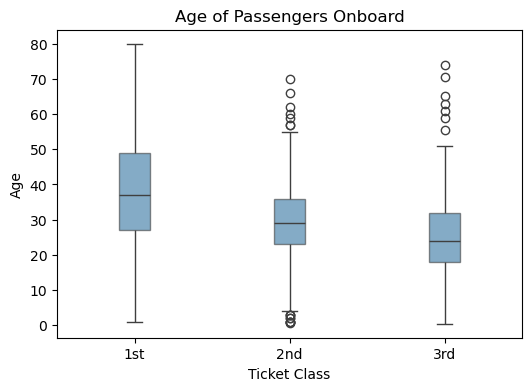

In [73]:
fig, ax=plt.subplots(figsize=(6,4))
sns.boxplot(data=titanic, x='Pclass', y='Age', width=0.2,boxprops=dict(alpha=0.6))

ax.set_xlabel("Ticket Class")
ax.set_title("Age of Passengers Onboard")
ax.set_xticklabels(("1st","2nd","3rd"))
plt.show()

#### ii. describe the passengers’ age using boxplots on age based on survival

C:\Users\shani\AppData\Local\Temp\ipykernel_22908\272616994.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(("No","Yes"))


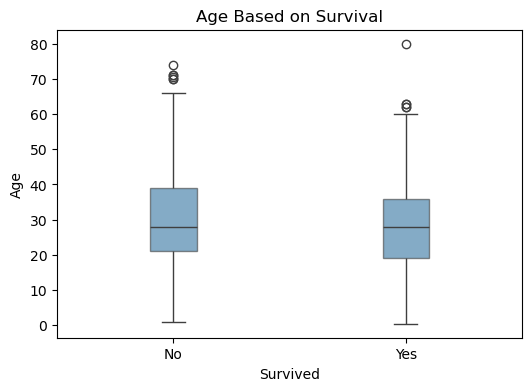

In [79]:
fig, ax=plt.subplots(figsize=(6,4))
sns.boxplot(data=titanic, x='Survived', y='Age', width=0.2, boxprops=dict(alpha=0.6))

ax.set_xlabel("Survived")
ax.set_title("Age Based on Survival")
ax.set_xticklabels(("No","Yes"))
plt.show()

### 3.Generate a histogram for the travel fare and a table showing the number of people who did not pay.

#### i. Generate a histogram for travel fare

<Axes: title={'center': 'Travel Fare'}, ylabel='Frequency'>

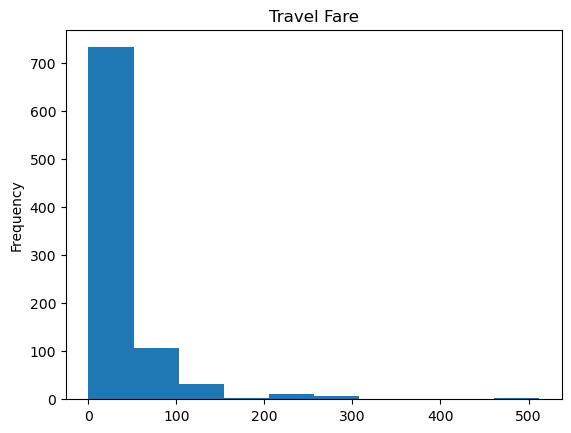

In [85]:
titanic['Fare'].plot(kind='hist', title="Travel Fare")

#### ii. Table showing the number of people who did not pay

In [96]:
notPaid = titanic[['Fare']].apply(lambda x: x==0).groupby('Fare').size()
notPaid

Fare
False    876
True      15
dtype: int64

### 4. A chart of your choice to describe the family size per ticket class.

#### i. Stacked bar graph to describe family size per ticket class

[Text(0, 0, '1st'), Text(1, 0, '2nd'), Text(2, 0, '3rd')]

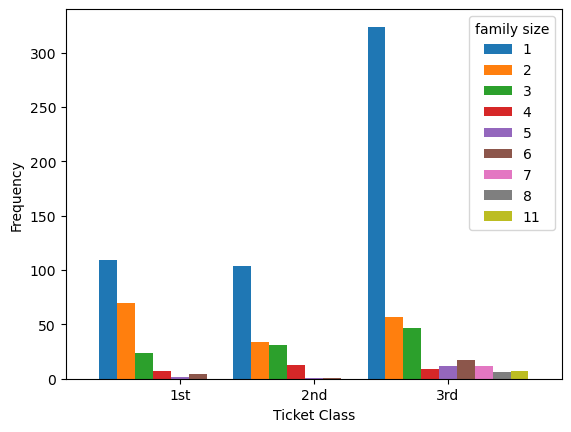

In [144]:
ax = titanic.groupby(['Pclass','family size']).size().unstack().fillna(0).plot.bar(width=1.2, xlabel="Ticket Class", ylabel="Frequency")
ax.set_xticklabels(("1st","2nd","3rd"), rotation=0)

#### ii. Historgram to describe family size per ticket class

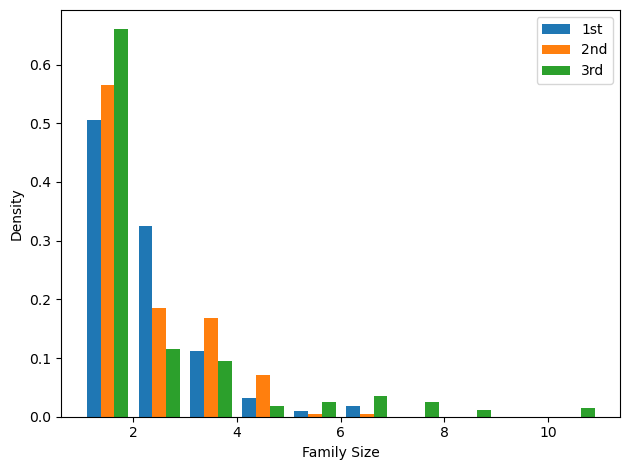

In [104]:
fig, ax=plt.subplots()
ax.hist([titanic.loc[titanic.Pclass==class_idx,"family size"] for class_idx in range(1,4)], density=True, label=["1st","2nd","3rd"])

ax.set_xlabel("Family Size")
ax.set_ylabel("Density")
plt.tight_layout()
plt.legend(loc='upper right')
plt.show()

### 5. A series of stacked bar charts to show how survival differs for different gender and ticket class.

#### i. A series of stacked bar charts to show how survival differs for different gender.

[Text(0, 0, 'No'), Text(1, 0, 'Yes')]

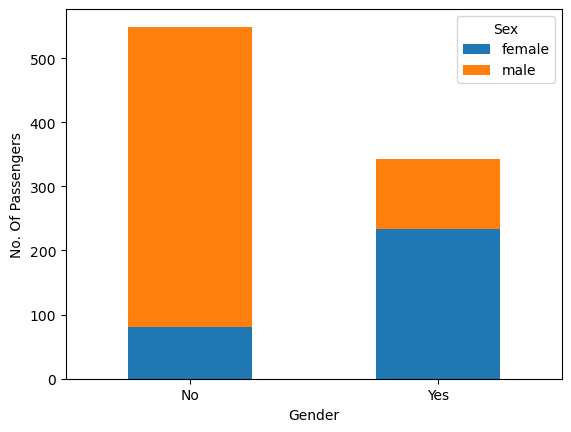

In [142]:
ax = titanic.groupby(['Survived','Sex']).size().unstack().fillna(0)
ax = ax.plot(kind='bar', stacked=True, xlabel="Gender", ylabel="No. Of Passengers")
ax.set_xticklabels(["No","Yes"], rotation=0)

#### ii. A series of stacked bar charts to show how survival differs for different ticket class.

[Text(0, 0, 'No'), Text(1, 0, 'Yes')]

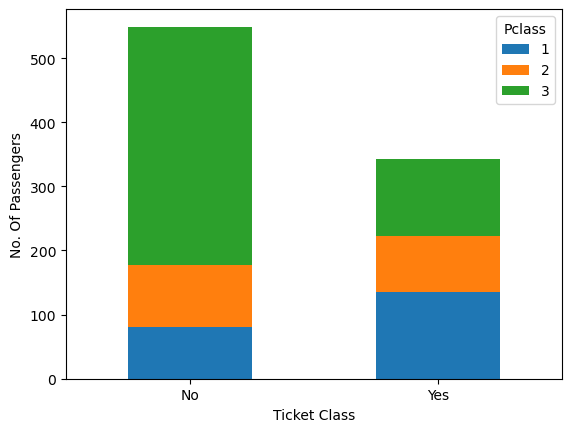

In [156]:
ax = titanic.groupby(['Survived','Pclass']).size().unstack().fillna(0)
ax = ax.plot(kind='bar', stacked=True, xlabel="Ticket Class", ylabel="No. Of Passengers")
ax.set_xticklabels(["No","Yes"], rotation=0)

### 6. A violin chart describing how survival related to age and gender.

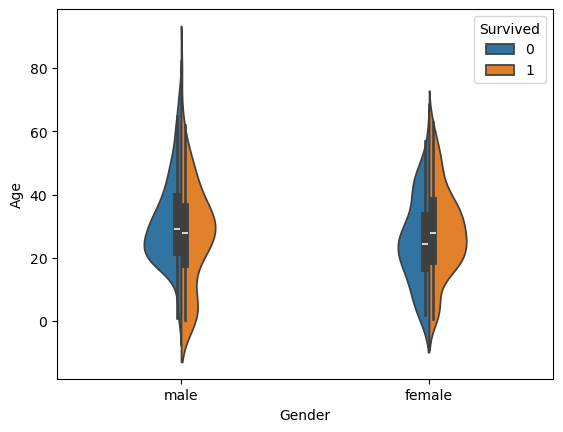

In [162]:
ax = sns.violinplot(data=titanic, x='Sex', y='Age', hue='Survived', width=0.3, split=True)
ax.set_xlabel("Gender")
plt.show()

### 7. A violin chart describing the survival rate related to age and ticket class. 

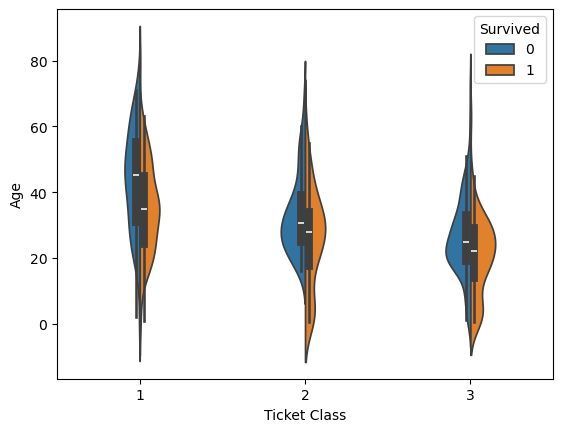

In [171]:
ax = sns.violinplot(data=titanic, x='Pclass', y='Age', hue='Survived', width=0.3, split=True)
ax.set_xlabel("Ticket Class")
plt.show()